🚀 启动自动化参数空间扫描...

🎯 U_C = 1.5      | R² = 0.99094 | 前100点平均误差 = 4.5954 | 耗时: 1.4s
🎯 U_C = 1.5437   | R² = 0.98878 | 前100点平均误差 = 5.1269 | 耗时: 0.7s
🎯 U_C = 1.55     | R² = 0.98987 | 前100点平均误差 = 4.7788 | 耗时: 0.7s
🎯 U_C = 1.7548   | R² = 0.98913 | 前100点平均误差 = 5.0819 | 耗时: 0.8s
🎯 U_C = 1.85     | R² = 0.98747 | 前100点平均误差 = 5.2696 | 耗时: 0.8s
🎯 U_C = 2.0      | R² = 0.99102 | 前100点平均误差 = 4.4985 | 耗时: 0.8s


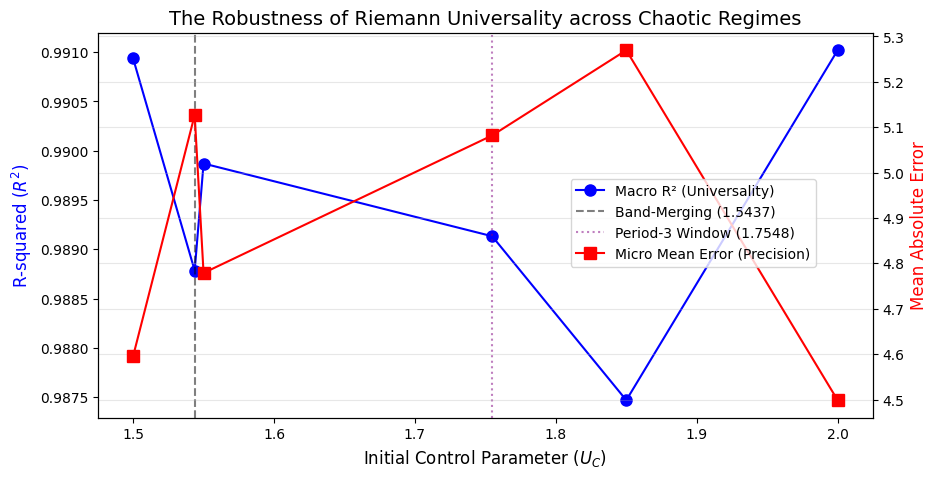

In [1]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import eigs
from scipy.stats import linregress
import mpmath
import matplotlib.pyplot as plt
import time
from numba import njit

# 真实的黎曼零点
mpmath.mp.dps = 15
N_ZEROS = 100
TRUE_ZEROS = np.array([float(mpmath.zetazero(i).imag) for i in range(1, N_ZEROS + 1)])

@njit
def run_universe(steps, n_bins, u_c, k_opt):
    transitions = np.zeros((n_bins, n_bins), dtype=np.uint32)
    x = 0.5
    last_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
    for i in range(1, steps + 1):
        # 统一使用绝对安全的退火模式 (确保不会 > 2.0)
        mu = u_c - k_opt / (np.log(i + 10**6)**2) 
        x = 1.0 - mu * x * x
        if x > 1.0: x = 0.999
        elif x < -1.0: x = -0.999
        current_bin = int((x + 1.0) / 2.0 * (n_bins - 1))
        transitions[last_bin, current_bin] += 1
        last_bin = current_bin
    return transitions

# 实习生的狙击清单
test_points = [1.50, 1.5437, 1.55, 1.7548, 1.85, 2.0]
results_R2 = []
results_mean_err = []

print("🚀 启动自动化参数空间扫描...\n")

for u in test_points:
    start_t = time.time()
    # 使用 10^7 步进行快速扫描评估
    trans = run_universe(10**7, 5000, u, 12.32)
    
    P_sparse = sp.csr_matrix(trans, dtype=np.float64)
    row_sums = np.array(P_sparse.sum(axis=1)).flatten()
    row_sums[row_sums == 0] = 1.0 
    P_sparse.data /= row_sums[P_sparse.indices]
    
    eigenvalues, _ = eigs(P_sparse, k=N_ZEROS + 20, which='LM', tol=1e-4)
    phases = np.sort(np.angle(eigenvalues[np.abs(eigenvalues.imag) > 1e-4]))
    unwrapped = np.unwrap(phases)[:N_ZEROS]
    
    slope, intercept, r_val, _, _ = linregress(unwrapped, TRUE_ZEROS)
    pred = slope * unwrapped + intercept
    
    err = np.mean(np.abs(pred - TRUE_ZEROS))
    r2 = r_val**2
    
    results_R2.append(r2)
    results_mean_err.append(err)
    
    print(f"🎯 U_C = {u:<8} | R² = {r2:.5f} | 前100点平均误差 = {err:.4f} | 耗时: {time.time()-start_t:.1f}s")

# 画一张给审稿人看的结论图
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(test_points, results_R2, 'b-o', markersize=8, label='Macro R² (Universality)')
ax2.plot(test_points, results_mean_err, 'r-s', markersize=8, label='Micro Mean Error (Precision)')

ax1.axvline(1.543689, color='k', linestyle='--', alpha=0.5, label='Band-Merging (1.5437)')
ax1.axvline(1.7548, color='purple', linestyle=':', alpha=0.5, label='Period-3 Window (1.7548)')

ax1.set_xlabel('Initial Control Parameter ($U_C$)', fontsize=12)
ax1.set_ylabel('R-squared ($R^2$)', color='b', fontsize=12)
ax2.set_ylabel('Mean Absolute Error', color='r', fontsize=12)
plt.title('The Robustness of Riemann Universality across Chaotic Regimes', fontsize=14)
fig.legend(loc='center right', bbox_to_anchor=(0.85, 0.5))
plt.grid(True, alpha=0.3)
plt.show()